In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/content/drive/MyDrive/oil_spill_project/models/best_model.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print("✅ Best model loaded and set to eval mode")


✅ Best model loaded and set to eval mode


In [ ]:
class OilSpillDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        # CRITICAL: iterate using masks, not images
        self.mask_files = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.mask_files)

    def __getitem__(self, idx):
        mask_name = self.mask_files[idx]

        img_path = os.path.join(self.img_dir, mask_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # Load image
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise RuntimeError(f"Image missing for mask: {mask_name}")

        # Load mask (guaranteed to exist)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Normalize
        image = image / 255.0
        mask = mask / 255.0

        # To tensor
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask


In [ ]:
test_dataset = OilSpillDataset(
    "/content/drive/MyDrive/oil_spill_project/data/sentinel/tiles/primary_test/images",
    "/content/drive/MyDrive/oil_spill_project/data/sentinel/tiles/primary_test/masks"
)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


In [ ]:
def visualize_sample(image, gt, pred):
    import numpy as np
    import matplotlib.pyplot as plt

    image = image.squeeze().cpu().numpy()
    gt = gt.squeeze().cpu().numpy()
    pred = pred.squeeze().cpu().numpy()

    fig, ax = plt.subplots(1, 4, figsize=(16,4))

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title("SAR Image")

    ax[1].imshow(gt, cmap="gray")
    ax[1].set_title("Ground Truth")

    ax[2].imshow(pred, cmap="gray")
    ax[2].set_title("Prediction")

    ax[3].imshow(image, cmap="gray")

    ax[3].imshow(pred, cmap="Greens",alpha=0.45)
    ax[3].set_title("Overlay")

    for a in ax:
        a.axis("off")
    plt.show()


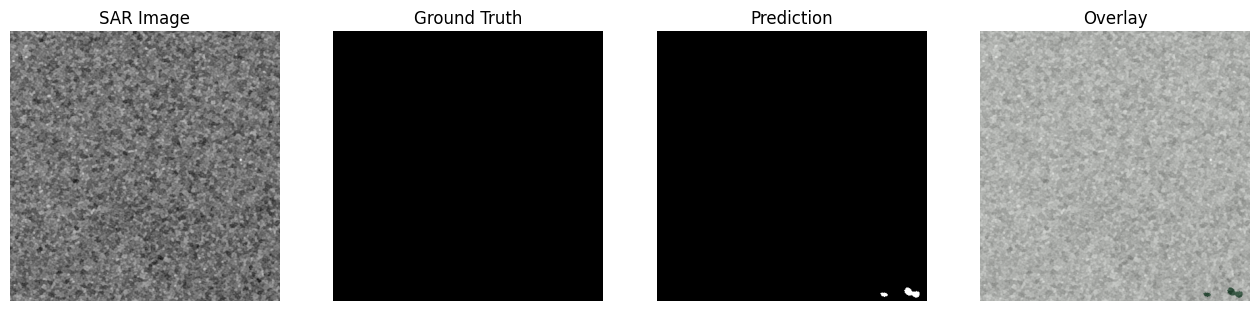

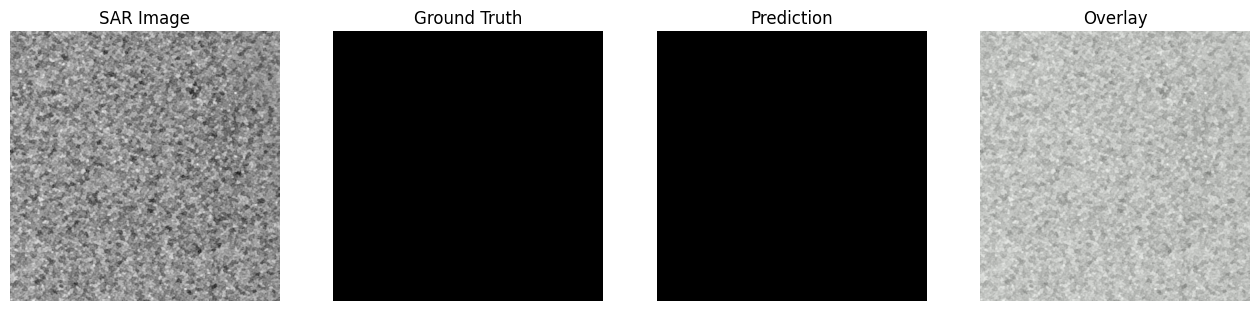

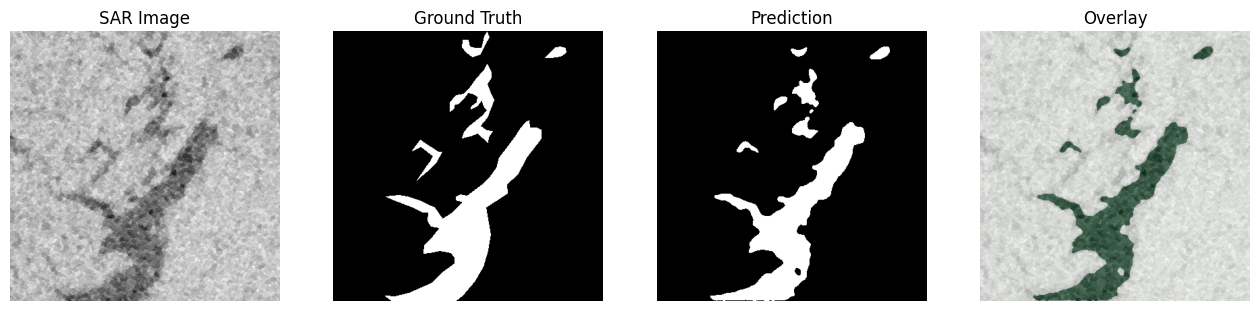

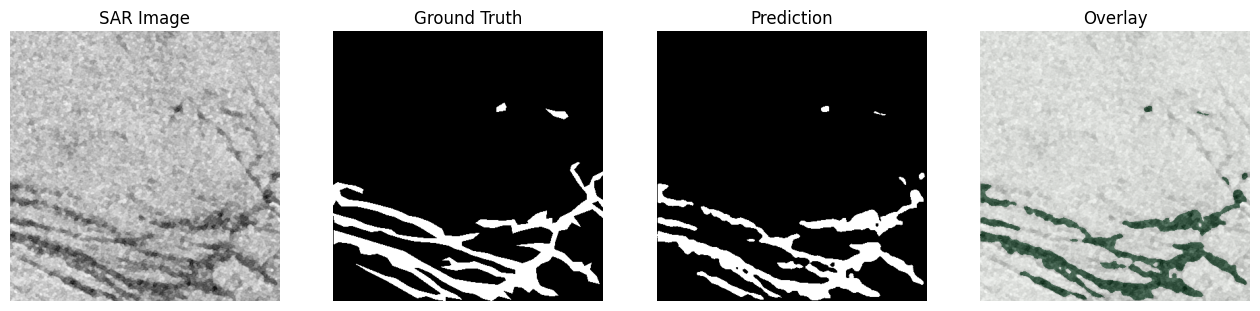

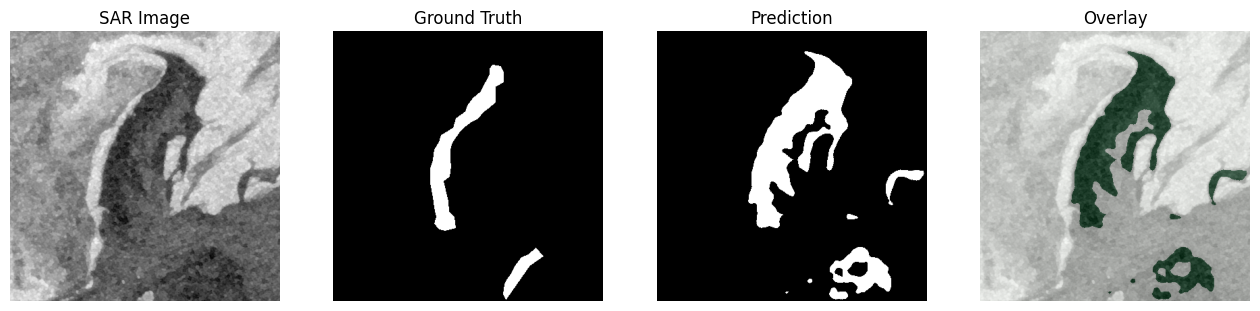

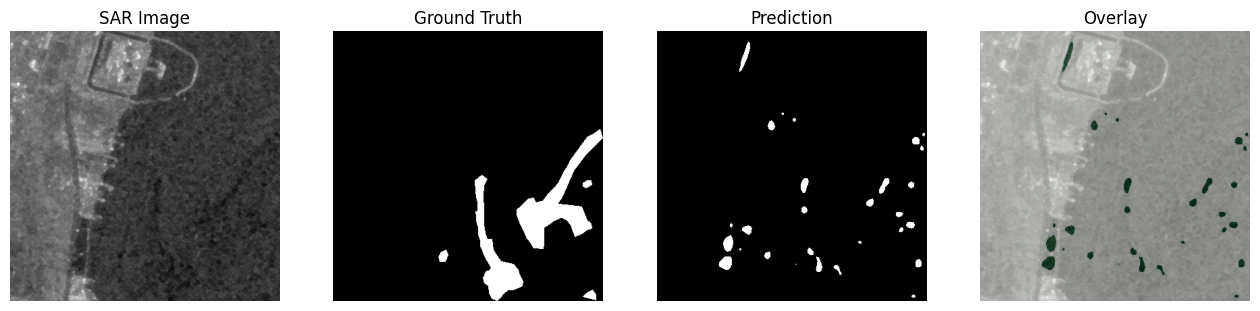

In [ ]:


BASE_PATH = "/content/drive/MyDrive/oil_spill_project/data/sentinel/tiles/primary_test"
IMG_DIR = os.path.join(BASE_PATH, "images")
MASK_DIR = os.path.join(BASE_PATH, "masks")

# EXPLICITLY SELECTED FILES
# (2 ocean, 2 oil, 2 coastal)
selected_masks = [
    "aug09_00327.png",  # ocean
    "aug09_01084.png",  # ocean
    "aug09_00754.png",  # oil
    "aug09_01575.png",  # oil
    "aug12_02974.png",  # coastal
    "aug12_02267.png"   # coastal
]

model.eval()

with torch.no_grad():
    for mask_name in selected_masks:
        img_path = os.path.join(IMG_DIR, mask_name)
        mask_path = os.path.join(MASK_DIR, mask_name)


        # Load image & mask
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            print(f" Missing file: {mask_name}")
            continue

        # Normalize
        image = image / 255.0
        mask = mask / 255.0

        # To tensor (1, 1, H, W)
        img_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        # Predict
        pred = torch.sigmoid(model(img_tensor))
        pred = (pred > 0.5).float()

        # Visualize
        visualize_sample(img_tensor, mask_tensor, pred)


In [ ]:
def dice_score(pred, target, eps=1e-6):
    intersection = (pred * target).sum()
    return (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

def iou_score(pred, target, eps=1e-6):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + eps) / (union + eps)


In [ ]:
dice_scores = []
iou_scores = []

with torch.no_grad():
    for img, mask in test_loader:
        img = img.to(device)
        mask = mask.to(device)

        pred = torch.sigmoid(model(img))
        pred = (pred > 0.5).float()

        dice_scores.append(dice_score(pred, mask).item())
        iou_scores.append(iou_score(pred, mask).item())

print(f"📊 Mean Dice: {np.mean(dice_scores):.4f}")
print(f"📊 Mean IoU : {np.mean(iou_scores):.4f}")


📊 Mean Dice: 0.1509
📊 Mean IoU : 0.1488


In [ ]:
dice_scores_oil = []
iou_scores_oil = []

oil_tile_count = 0
skipped_ocean_tiles = 0

model.eval()
with torch.no_grad():
    for img, mask in test_loader:
        img = img.to(device)
        mask = mask.to(device)

        # Check if this tile has oil in GT
        if mask.sum().item() == 0:
            skipped_ocean_tiles += 1
            continue  # skip clean ocean tiles

        oil_tile_count += 1

        # Predict
        pred = torch.sigmoid(model(img))
        pred = (pred > 0.2).float()

        # Compute metrics
        dice = dice_score(pred, mask).item()
        iou = iou_score(pred, mask).item()

        dice_scores_oil.append(dice)
        iou_scores_oil.append(iou)

print(" Oil tiles evaluated:", oil_tile_count)
print(" Ocean tiles skipped:", skipped_ocean_tiles)

print(f"📊 Mean Dice (oil tiles only): {sum(dice_scores_oil)/len(dice_scores_oil):.4f}")
print(f"📊 Mean IoU  (oil tiles only): {sum(iou_scores_oil)/len(iou_scores_oil):.4f}")


 Oil tiles evaluated: 59
 Ocean tiles skipped: 16
📊 Mean Dice (oil tiles only): 0.0043
📊 Mean IoU  (oil tiles only): 0.0022


In [ ]:
import cv2
import numpy as np

def postprocess_mask(pred_mask, min_area=10, max_area=1500):
    """
    pred_mask: numpy array (H, W), binary {0,1}
    returns: cleaned binary mask
    """

    pred_mask = pred_mask.astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        pred_mask, connectivity=8
    )

    cleaned = np.zeros_like(pred_mask)

    for i in range(1, num_labels):  # skip background
        area = stats[i, cv2.CC_STAT_AREA]

        if min_area <= area <= max_area:
            cleaned[labels == i] = 1

    return cleaned


In [ ]:
dice_scores_oil = []
iou_scores_oil = []

oil_tile_count = 0
skipped_ocean_tiles = 0

model.eval()
with torch.no_grad():
    for img, mask in test_loader:
        img = img.to(device)
        mask = mask.to(device)

        # Skip clean ocean tiles
        if mask.sum().item() == 0:
            skipped_ocean_tiles += 1
            continue

        oil_tile_count += 1

        # Model prediction
        pred = torch.sigmoid(model(img))

        # threshold (keep low for recall)
        pred = (pred > 0.2).float()

        # POST-PROCESSING (THIS IS THE CRITICAL PART)
        pred_np = pred.squeeze().cpu().numpy()          # (H, W)
        pred_clean = postprocess_mask(
            pred_np,
            min_area=10,
            max_area=1500
        )

        # back to tensor
        pred = torch.tensor(pred_clean, dtype=torch.float32)\
                    .unsqueeze(0).unsqueeze(0).to(device)

        # Metrics
        dice = dice_score(pred, mask).item()
        iou = iou_score(pred, mask).item()

        dice_scores_oil.append(dice)
        iou_scores_oil.append(iou)

# Final results
print(" Oil tiles evaluated:", oil_tile_count)
print(" Ocean tiles skipped:", skipped_ocean_tiles)

print(f"📊 Mean Dice (oil tiles only, post-processed): {np.mean(dice_scores_oil):.4f}")
print(f"📊 Mean IoU  (oil tiles only, post-processed): {np.mean(iou_scores_oil):.4f}")


 Oil tiles evaluated: 59
 Ocean tiles skipped: 16
📊 Mean Dice (oil tiles only, post-processed): 0.0024
📊 Mean IoU  (oil tiles only, post-processed): 0.0012


In [ ]:
PIXEL_AREA_M2 = 100        # 10m x 10m
M2_TO_KM2 = 1_000_000

gt_areas = []
pred_areas = []
area_errors = []
overestimation_ratios = []

oil_tile_count = 0

model.eval()
with torch.no_grad():
    for img, mask in test_loader:
        img = img.to(device)
        mask = mask.to(device)

        # Only oil tiles
        if mask.sum().item() == 0:
            continue

        oil_tile_count += 1

        # Ground truth area
        gt_pixels = mask.sum().item()
        gt_area_km2 = (gt_pixels * PIXEL_AREA_M2) / M2_TO_KM2

        # Model prediction
        pred = torch.sigmoid(model(img))
        pred = (pred > 0.2).float()

        pred_np = pred.squeeze().cpu().numpy()
        pred_clean = postprocess_mask(pred_np)

        pred_pixels = pred_clean.sum()
        pred_area_km2 = (pred_pixels * PIXEL_AREA_M2) / M2_TO_KM2

        # Errors
        area_error = abs(pred_area_km2 - gt_area_km2)
        over_ratio = pred_area_km2 / (gt_area_km2 + 1e-6)

        # Store
        gt_areas.append(gt_area_km2)
        pred_areas.append(pred_area_km2)
        area_errors.append(area_error)
        overestimation_ratios.append(over_ratio)

print(" Oil tiles evaluated:", oil_tile_count)

print(f"GT oil area (km²):   mean={np.mean(gt_areas):.6f}, max={np.max(gt_areas):.6f}")
print(f"Pred oil area (km²): mean={np.mean(pred_areas):.6f}, max={np.max(pred_areas):.6f}")

print(f"Mean absolute area error (km²): {np.mean(area_errors):.6f}")
print(f"Median overestimation ratio:   {np.median(overestimation_ratios):.2f}×")



 Oil tiles evaluated: 59
GT oil area (km²):   mean=0.004410, max=0.030955
Pred oil area (km²): mean=0.371615, max=1.397200
Mean absolute area error (km²): 0.367845
Median overestimation ratio:   94.60×
